In [1]:
import pandas as pd
import numpy as np

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 2.3.3
numpy version: 2.0.2


In [2]:
import numpy as np

def gini_coefficient(incomes):
    incomes = np.array(incomes)
    n = len(incomes)
    mean_income = np.mean(incomes)
    
    # sum of |x_i - x_j| over all pairs
    total_diff = 0
    for i in range(n):
        for j in range(n):
            total_diff += abs(incomes[i] - incomes[j])
    
    gini = total_diff / (2 * n**2 * mean_income)
    return gini

    # everyone has the same income -> should print 0.0
print(gini_coefficient([50, 50, 50, 50]))

# one person has everything, rest have nothing 
# should print a number close to 1
print(gini_coefficient([1, 1, 1, 1000]))

# mixed example
print(gini_coefficient([50, 50, 70, 70, 70, 90, 150, 150, 150, 150]))

0.0
0.7470089730807578
0.226


In [3]:
def spectral_gap(transition_matrix):
    matrix = np.array(transition_matrix)
    eigenvalues = np.linalg.eigvals(matrix)
    
    # sort eigenvalues by absolute value, descending
    sorted_eigs = sorted(eigenvalues, key=abs, reverse=True)
    
    largest = sorted_eigs[0]
    second_largest = sorted_eigs[1]
    
    gap = 1 - abs(second_largest)
    return gap, second_largest

sticky_matrix = [
    [0.6, 0.3, 0.1],
    [0.2, 0.6, 0.2],
    [0.1, 0.3, 0.6]
]

gap, second_eig = spectral_gap(sticky_matrix)
print("Second eigenvalue:", second_eig)
print("Spectral gap:", gap)

mobile_matrix = [
    [0.34, 0.33, 0.33],
    [0.33, 0.34, 0.33],
    [0.33, 0.33, 0.34]
]

gap2, second_eig2 = spectral_gap(mobile_matrix)
print("Second eigenvalue:", second_eig2)
print("Spectral gap:", gap2)

Second eigenvalue: 0.4999999999999997
Spectral gap: 0.5000000000000002
Second eigenvalue: 0.010000000000000004
Spectral gap: 0.99


In [4]:
def simulate_population(transition_matrix, initial_distribution, generations, income_values):
    matrix = np.array(transition_matrix)
    distribution = np.array(initial_distribution) 
    
    history = []
    for gen in range(generations):
        # distribution is fraction of population in each group
        history.append(distribution.copy())
        distribution = distribution @ matrix  # one generation's transition
    
    return history

initial = [1.0, 0.0, 0.0]  # everyone starts in low income
history = simulate_population(sticky_matrix, initial, generations=10, income_values=[30, 60, 120])

for i, dist in enumerate(history):
    print(f"Generation {i}: {dist}")

Generation 0: [1. 0. 0.]
Generation 1: [0.6 0.3 0.1]
Generation 2: [0.43 0.39 0.18]
Generation 3: [0.354 0.417 0.229]
Generation 4: [0.3187 0.4251 0.2562]
Generation 5: [0.30186 0.42753 0.27061]
Generation 6: [0.293683 0.428259 0.278058]
Generation 7: [0.2896674 0.4284777 0.2818549]
Generation 8: [0.28768147 0.42854331 0.28377522]
Generation 9: [0.28669507 0.42856299 0.28474194]


In [5]:
def distribution_to_incomes(distribution, income_values, population_size=10000):
    incomes = []
    for fraction, income in zip(distribution, income_values):
        count = int(round(fraction * population_size))
        incomes.extend([income] * count)
    return incomes

In [6]:
final_distribution = history[-1]  # last generation 
income_values = [30, 60, 120]

incomes = distribution_to_incomes(final_distribution, income_values)
steady_state_gini = gini_coefficient(incomes)

print("Steady-state distribution:", final_distribution)
print("Steady-state Gini coefficient:", steady_state_gini)

Steady-state distribution: [0.28669507 0.42856299 0.28474194]
Steady-state Gini coefficient: 0.2680137249748106


In [7]:
history_mobile = simulate_population(mobile_matrix, initial, generations=20, income_values=[30, 60, 120])
final_dist_mobile = history_mobile[-1]

incomes_mobile = distribution_to_incomes(final_dist_mobile, income_values)
gini_mobile = gini_coefficient(incomes_mobile)

print("Mobile matrix steady-state distribution:", final_dist_mobile)
print("Mobile matrix Gini:", gini_mobile)
print("Mobile matrix spectral gap:", spectral_gap(mobile_matrix)[0])
print("---")
print("Sticky matrix Gini:", steady_state_gini)
print("Sticky matrix spectral gap:", spectral_gap(sticky_matrix)[0])

Mobile matrix steady-state distribution: [0.33333333 0.33333333 0.33333333]
Mobile matrix Gini: 0.2857142857142857
Mobile matrix spectral gap: 0.99
---
Sticky matrix Gini: 0.2680137249748106
Sticky matrix spectral gap: 0.5000000000000002


In [8]:
def random_transition_matrix(size=3):
    matrix = np.random.rand(size, size)
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix = matrix / row_sums
    return matrix

In [9]:
test_matrix = random_transition_matrix()
print(test_matrix)
print("Row sums:", test_matrix.sum(axis=1))

[[0.35878322 0.32021039 0.32100639]
 [0.6313544  0.29466176 0.07398383]
 [0.30014917 0.33156249 0.36828834]]
Row sums: [1. 1. 1.]


In [10]:
def gini_coefficient(incomes):
    incomes = np.sort(np.array(incomes))
    n = len(incomes)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * incomes) - (n + 1) * np.sum(incomes)) / (n * np.sum(incomes))

In [11]:
print(gini_coefficient([50, 50, 50, 50]))
print(gini_coefficient([1, 1, 1, 1000]))
print(gini_coefficient([50, 50, 70, 70, 70, 90, 150, 150, 150, 150]))

0.0
0.7470089730807578
0.226


In [12]:
spectral_gaps = []
gini_values = []

for i in range(50):
    matrix = random_transition_matrix(size=3)
    gap, _ = spectral_gap(matrix)
    
    initial = [1.0, 0.0, 0.0]
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    
    incomes = distribution_to_incomes(final_dist, income_values=[30, 60, 120])
    g = gini_coefficient(incomes)
    
    spectral_gaps.append(gap)
    gini_values.append(g)

print("Generated", len(spectral_gaps), "matrices")
print("First few spectral gaps:", spectral_gaps[:5])
print("First few Gini values:", gini_values[:5])

Generated 50 matrices
First few spectral gaps: [np.float64(0.7701033939966115), np.float64(0.6856322819132451), np.float64(0.6214221632693708), np.float64(0.9082625979863905), np.float64(0.967330906652572)]
First few Gini values: [np.float64(0.2946270385267261), np.float64(0.2774623418865197), np.float64(0.27758239134027435), np.float64(0.24193318082952073), np.float64(0.3242252401582219)]


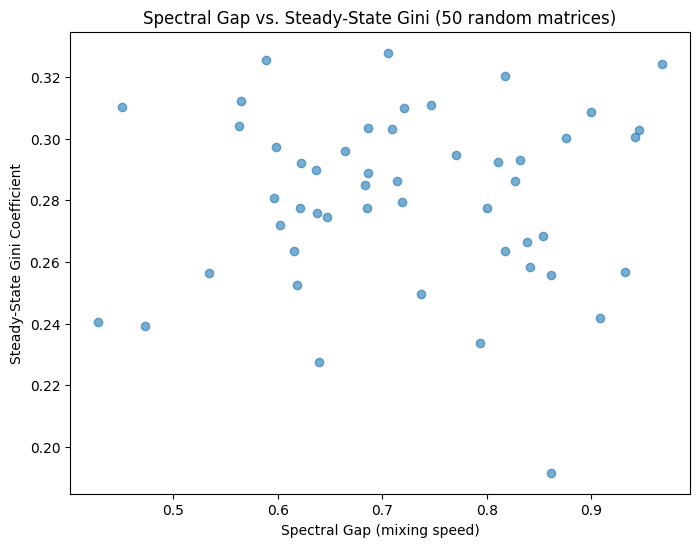

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(spectral_gaps, gini_values, alpha=0.6)
plt.xlabel("Spectral Gap (mixing speed)")
plt.ylabel("Steady-State Gini Coefficient")
plt.title("Spectral Gap vs. Steady-State Gini (50 random matrices)")
plt.show()

In [14]:
!pip install matplotlib

In [15]:
spectral_gaps = []
gini_values = []
matrices = []

for i in range(50):
    matrix = random_transition_matrix(size=3)
    gap, _ = spectral_gap(matrix)
    
    initial = [1.0, 0.0, 0.0]
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    
    incomes = distribution_to_incomes(final_dist, income_values=[30, 60, 120])
    g = gini_coefficient(incomes)
    
    spectral_gaps.append(gap)
    gini_values.append(g)
    matrices.append(matrix)

print("Generated", len(spectral_gaps), "matrices")

Generated 50 matrices


In [16]:
import numpy as np

gini_array = np.array(gini_values)

min_idx = np.argmin(gini_array)
max_idx = np.argmax(gini_array)

print("Lowest Gini:", gini_array[min_idx], "at spectral gap:", spectral_gaps[min_idx])
print("Matrix with lowest Gini:")
print(matrices[min_idx])
print()
print("Highest Gini:", gini_array[max_idx], "at spectral gap:", spectral_gaps[max_idx])
print("Matrix with highest Gini:")
print(matrices[max_idx])

Lowest Gini: 0.08663759894095259 at spectral gap: 0.6925627908886937
Matrix with lowest Gini:
[[0.1073563  0.54331862 0.34932508]
 [0.12074499 0.20474313 0.67451188]
 [0.01230813 0.1156536  0.87203827]]

Highest Gini: 0.32901485620856574 at spectral gap: 0.6130081377096608
Matrix with highest Gini:
[[0.50523986 0.08103675 0.41372339]
 [0.50516282 0.44596468 0.04887249]
 [0.73694079 0.04575562 0.21730359]]


In [17]:
initial = [1.0, 0.0, 0.0]

low_gini_history = simulate_population(matrices[min_idx], initial, generations=100, income_values=[30, 60, 120])
high_gini_history = simulate_population(matrices[max_idx], initial, generations=100, income_values=[30, 60, 120])

print("Low-Gini matrix steady state:", low_gini_history[-1])
print("High-Gini matrix steady state:", high_gini_history[-1])

Low-Gini matrix steady state: [0.03053223 0.14129947 0.82816829]
High-Gini matrix steady state: [0.57756314 0.11025958 0.31217728]


In [18]:
def distribution_entropy(distribution):
    """
    Computes entropy of a distribution - measures how spread out it is.
    High entropy = spread evenly across groups.
    Low entropy = concentrated in one group.
    """
    distribution = np.array(distribution)
    # avoid log(0) issues by filtering out zero entries
    nonzero = distribution[distribution > 0]
    return -np.sum(nonzero * np.log(nonzero))

In [19]:
# perfectly spread out across 3 groups -> should be HIGH entropy
print(distribution_entropy([1/3, 1/3, 1/3]))

# perfectly concentrated in one group -> should be 0 (LOWEST possible entropy)
print(distribution_entropy([1.0, 0.0, 0.0]))

# somewhere in between
print(distribution_entropy([0.6, 0.3, 0.1]))

1.0986122886681096
-0.0
0.8979457248567797


In [20]:
entropy_values = []

for matrix in matrices:
    history = simulate_population(matrix, initial, generations=100, income_values=[30, 60, 120])
    final_dist = history[-1]
    ent = distribution_entropy(final_dist)
    entropy_values.append(ent)

print("Computed", len(entropy_values), "entropy values")
print("First few:", entropy_values[:5])

Computed 50 entropy values
First few: [np.float64(1.0623843649905662), np.float64(1.0646492802993688), np.float64(1.0822783034541819), np.float64(1.0671296465571045), np.float64(0.9314117535471884)]


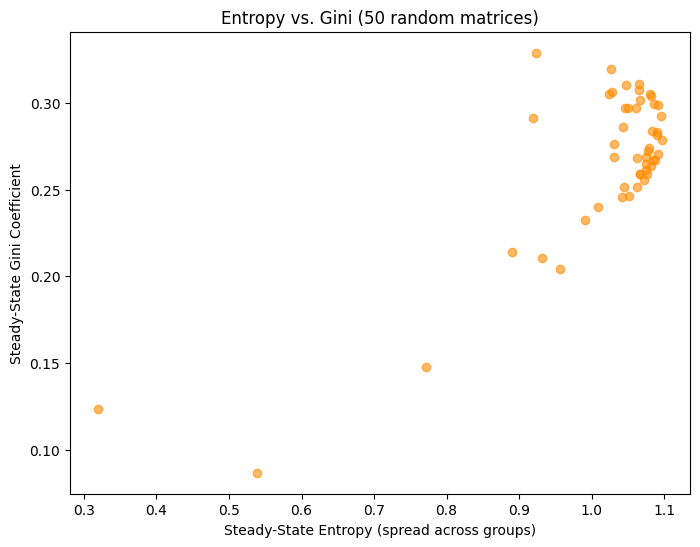

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(entropy_values, gini_values, alpha=0.6, color='darkorange')
plt.xlabel("Steady-State Entropy (spread across groups)")
plt.ylabel("Steady-State Gini Coefficient")
plt.title("Entropy vs. Gini (50 random matrices)")
plt.show()

In [22]:
!pip install scikit-learn

In [23]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.column_stack([spectral_gaps, entropy_values])  # two features
y = np.array(gini_values)

model = LinearRegression()
model.fit(X, y)

print("Coefficient for spectral gap:", model.coef_[0])
print("Coefficient for entropy:", model.coef_[1])
print("Intercept:", model.intercept_)
print("R² score:", model.score(X, y))

Coefficient for spectral gap: -0.022607589720626108
Coefficient for entropy: 0.2719636438352772
Intercept: 0.004153770346388752
R² score: 0.6169091377259017


In [24]:
def run_experiment(income_values, n_matrices=50, generations=100):

    sg_list = []
    ent_list = []
    gini_list = []
    
    initial = [1.0, 0.0, 0.0] + [0.0] * (len(income_values) - 3) if len(income_values) > 3 else [1.0, 0.0, 0.0]
    
    for i in range(n_matrices):
        matrix = random_transition_matrix(size=len(income_values))
        gap, _ = spectral_gap(matrix)
        
        history = simulate_population(matrix, initial, generations=generations, income_values=income_values)
        final_dist = history[-1]
        
        ent = distribution_entropy(final_dist)
        
        incomes = distribution_to_incomes(final_dist, income_values=income_values)
        g = gini_coefficient(incomes)
        
        sg_list.append(gap)
        ent_list.append(ent)
        gini_list.append(g)
    
    return sg_list, ent_list, gini_list

In [25]:
# Original spacing (uneven: 30, 60, 120)
sg1, ent1, gini1 = run_experiment([30, 60, 120])

# Evenly spaced
sg2, ent2, gini2 = run_experiment([30, 60, 90])

# More extreme spacing
sg3, ent3, gini3 = run_experiment([30, 60, 300])

print("Done running all three experiments")

Done running all three experiments


In [26]:
from sklearn.linear_model import LinearRegression

def check_entropy_gini_relationship(entropy_list, gini_list, label):
    X = np.array(entropy_list).reshape(-1, 1)
    y = np.array(gini_list)
    
    model = LinearRegression()
    model.fit(X, y)
    
    print(f"--- {label} ---")
    print("Entropy coefficient:", model.coef_[0])
    print("R² score:", model.score(X, y))
    print()

check_entropy_gini_relationship(ent1, gini1, "Uneven spacing: 30, 60, 120")
check_entropy_gini_relationship(ent2, gini2, "Even spacing: 30, 60, 90")
check_entropy_gini_relationship(ent3, gini3, "Extreme spacing: 30, 60, 300")

--- Uneven spacing: 30, 60, 120 ---
Entropy coefficient: 0.18484044231855656
R² score: 0.21193698047558163

--- Even spacing: 30, 60, 90 ---
Entropy coefficient: 0.30536523389916576
R² score: 0.4173042912979025

--- Extreme spacing: 30, 60, 300 ---
Entropy coefficient: 0.5760016486022037
R² score: 0.5929892059897732



In [27]:
def repeated_trials(income_values, n_trials=5, n_matrices=50):
   
    r2_scores = []
    
    for trial in range(n_trials):
        sg, ent, gini = run_experiment(income_values, n_matrices=n_matrices)
        
        X = np.array(ent).reshape(-1, 1)
        y = np.array(gini)
        model = LinearRegression()
        model.fit(X, y)
        
        r2_scores.append(model.score(X, y))
    
    return r2_scores

In [28]:
r2_uneven = repeated_trials([30, 60, 120])
r2_even = repeated_trials([30, 60, 90])
r2_extreme = repeated_trials([30, 60, 300])

print("Uneven (30,60,120) R² across trials:", r2_uneven)
print("Mean:", np.mean(r2_uneven), "Std:", np.std(r2_uneven))
print()
print("Even (30,60,90) R² across trials:", r2_even)
print("Mean:", np.mean(r2_even), "Std:", np.std(r2_even))
print()
print("Extreme (30,60,300) R² across trials:", r2_extreme)
print("Mean:", np.mean(r2_extreme), "Std:", np.std(r2_extreme))

Uneven (30,60,120) R² across trials: [0.7382269714984422, 0.6692846959656138, 0.3133732020490798, 0.04322556638150021, 0.2311219441846737]
Mean: 0.39904647601586196 Std: 0.2646579611624615

Even (30,60,90) R² across trials: [0.195299960413848, 0.15948205066650112, 0.5243677699938871, 0.41566948225125844, 0.006861985102866064]
Mean: 0.26033624968567215 Std: 0.18573720577384767

Extreme (30,60,300) R² across trials: [0.08798517161310737, 0.7041895711442046, 0.4626549444958338, 0.005018770708353548, 0.37460346187266347]
Mean: 0.32689038396683257 Std: 0.2544563877189884
